# 1. Análise Exploratória

In [1]:
# 1. Análise Exploratória
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# Não limitar o tamanho da resposta
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
train_csv = pd.read_csv("data/train.csv")

## 1.1 Distribuição das Variáveis

### 1.1.1 Características das Variáveis
Ao analisar o dataframe gerado abaixo, vemos que os dados são bem diferentes, com vários dados cotendo nulls, outliers e categorias diferentes.

In [3]:
def get_outlier(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3-q1
    lim_sup = q3+(iqr*1.5)
    lim_inf = q1-(iqr*1.5)
    return series[(series < lim_inf) | (series > lim_sup)]

def set_outliers(series: pd.Series):
    if not pd.api.types.is_numeric_dtype(series.dtype):
        return "Não elegível"
    if get_outlier(series).any():
        return "Sim"
    return "Não"

exploracao_csv = pd.DataFrame(
    {
        "categoria": train_csv.dtypes.map(lambda x: "Numérico" if x.kind in "iufc" else "Categórico"),
        "tem_null": train_csv.isna().sum().map(lambda x: "Sim" if x >= 1 else "Não"),
        "tem_outliers": train_csv.apply(set_outliers)
    }
)

exploracao_csv.sort_values(by=["categoria", "tem_null", "tem_outliers"])

,categoria,tem_null,tem_outliers
MSZoning,Categórico,Não,Não elegível
Street,Categórico,Não,Não elegível
LotShape,Categórico,Não,Não elegível
LandContour,Categórico,Não,Não elegível
Utilities,Categórico,Não,Não elegível
LotConfig,Categórico,Não,Não elegível
LandSlope,Categórico,Não,Não elegível
Neighborhood,Categórico,Não,Não elegível
Condition1,Categórico,Não,Não elegível
Condition2,Categórico,Não,Não elegível


### 1.1.2 Distribuição do Preço de Venda das Propriedades
Observando o histograma com a linha de densidade (KDE), podemos destacar os seguintes pontos importantes:
1. **Assimetria Positiva:** A distribuição dos preços não é uma curva normal perfeita (simétrica). Ela possui uma assimetria à direita, formando uma "cauda longa" que se estende para os valores mais altos.
2. **Concentração de Valores:** A grande maioria dos imóveis é vendida por um preço entre **$100.000 e $200.000**. O pico principal do gráfico ocorre próximo aos $150.000.
3. **Presença de Outliers:** A cauda longa à direita deixa claro que existem propriedades com preços de venda muito acima da maioria, chegando a valores que ultrapassam a marca de **$700.000**. Embora sejam poucos imóveis (frequência baixa), eles impactam as métricas globais, puxando a média de preços para cima.

Isso implica que utilizar uma transformação matemática como a transformação logarítmica trará muitos benefícios nas etapas de machine learning.

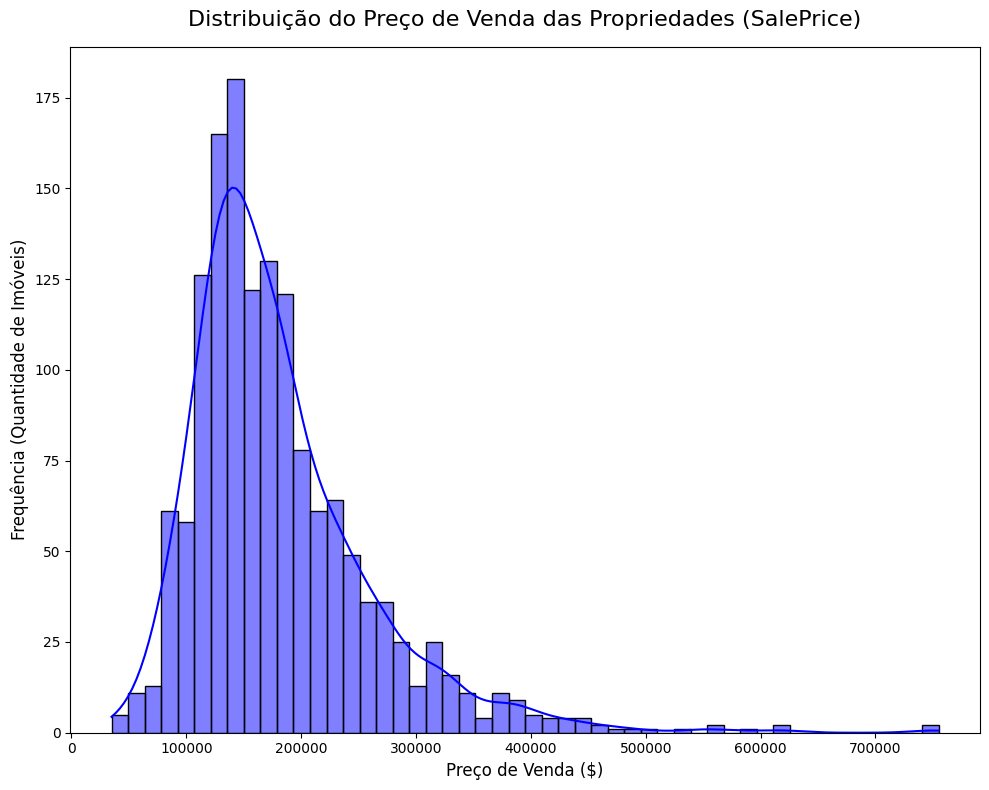

In [4]:
plt.figure(figsize=(10,8))
sb.histplot(
    train_csv["SalePrice"], kde=True, bins=50, color="blue"
)
plt.title("Distribuição do Preço de Venda das Propriedades (SalePrice)", fontsize=16, pad=15)
plt.xlabel("Preço de Venda ($)", fontsize=12)
plt.ylabel("Frequência (Quantidade de Imóveis)", fontsize=12)

plt.tight_layout()
plt.show()


## 1.2 Correlações e Dispersões

### 1.2.1 Gráfico de Correlação Geral
Olhando a matriz gerada abaixo, fica um pouco complicado analisar as correlações devido a grande quantidade de variáveis.

Então nós vamos utilizar outra forma...

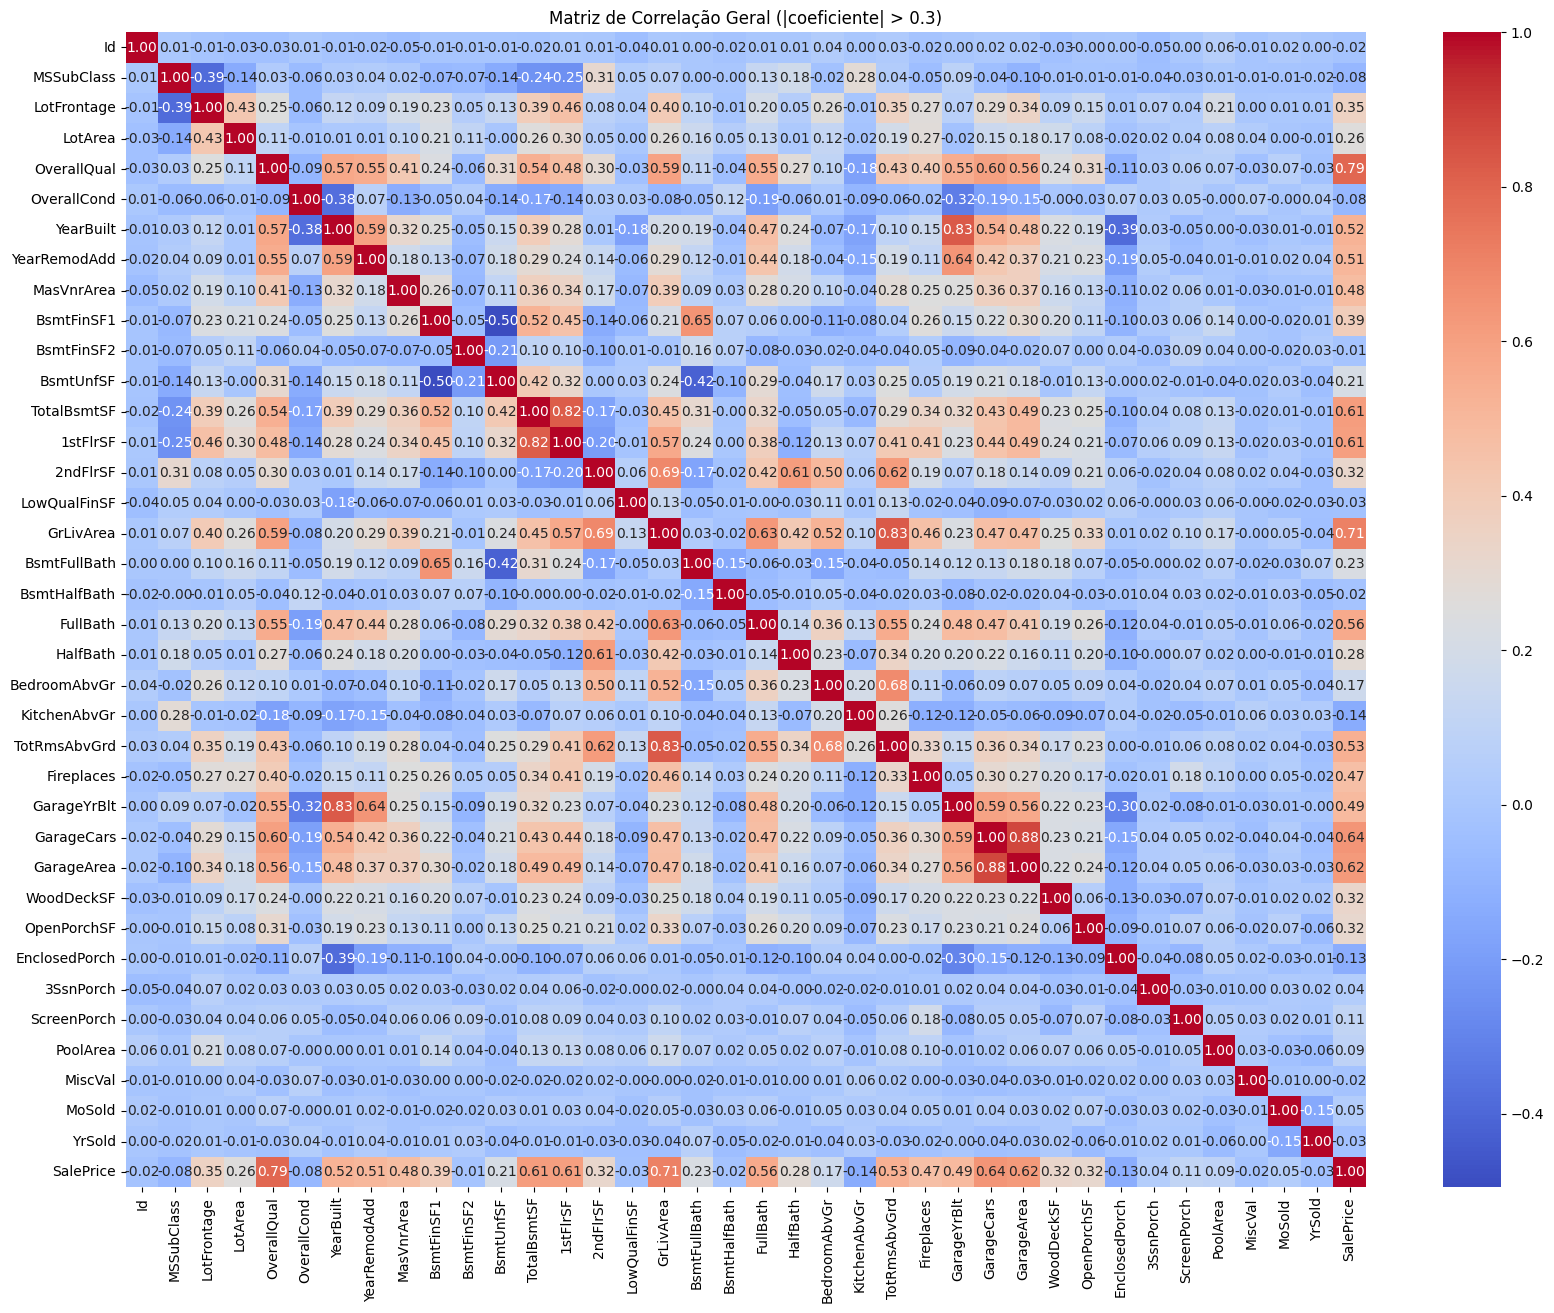

In [5]:
corr_matrix = train_csv.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação Geral (|coeficiente| > 0.3)")
plt.show()

### 1.2.1 Correlações com a variável de preço da propriedade (SalePrice)

Fizemos um filtro nos coeficientes de correlação absolutos das variáveis pegando somente as variáveis com um coeficiente relevante.

Assim a análise fica mais prática.

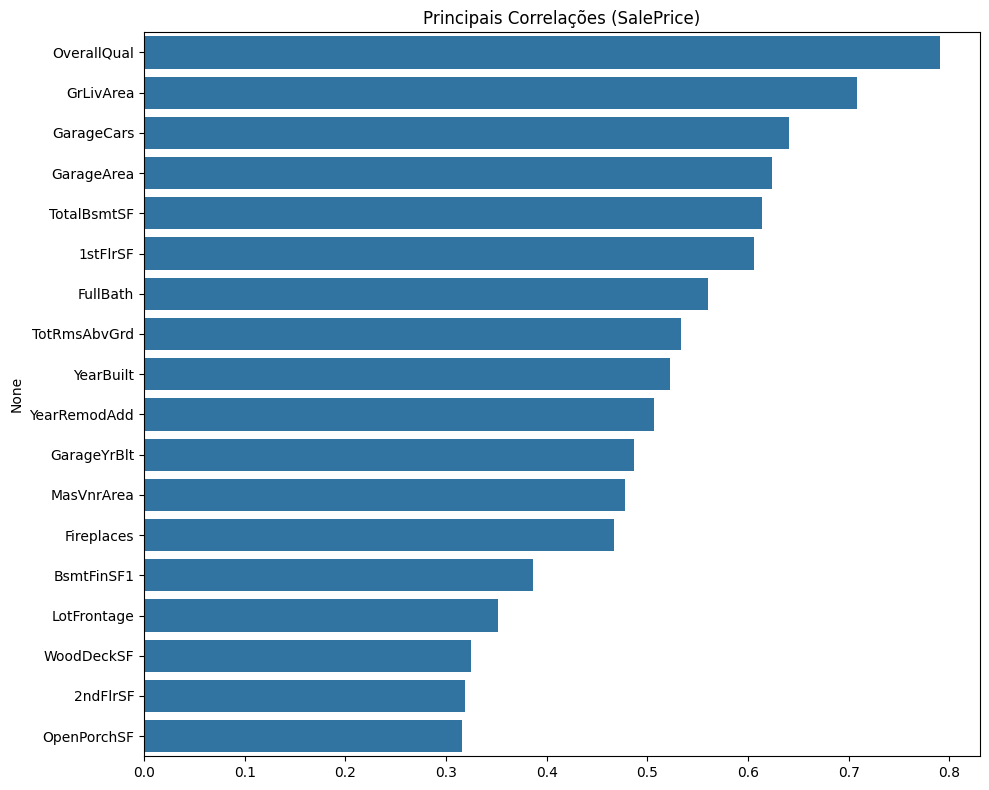

In [6]:
corr = train_csv.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).drop("SalePrice")

corr = corr.to_frame(name="correlation")
corr["abs_correlation"] = corr["correlation"].abs()

# Pega todas as variáveis com correlação absoluta maior ou igual que 0.3
best_corr = corr[corr["abs_correlation"] >= 0.3].sort_values(by="abs_correlation", ascending=False)

plt.figure(figsize=(10, 8))
sb.barplot(
    x=best_corr["correlation"].values,
    y=best_corr.index,
)
plt.title("Principais Correlações (SalePrice)")
plt.tight_layout()
plt.show()



### 1.2.2 Dispersão entre a área da propriedade e o preço (GrLivArea x SalePrice)
Aplicando um scatter plot na área habitável, vemos que quanto maior a área, maior o preço de venda.

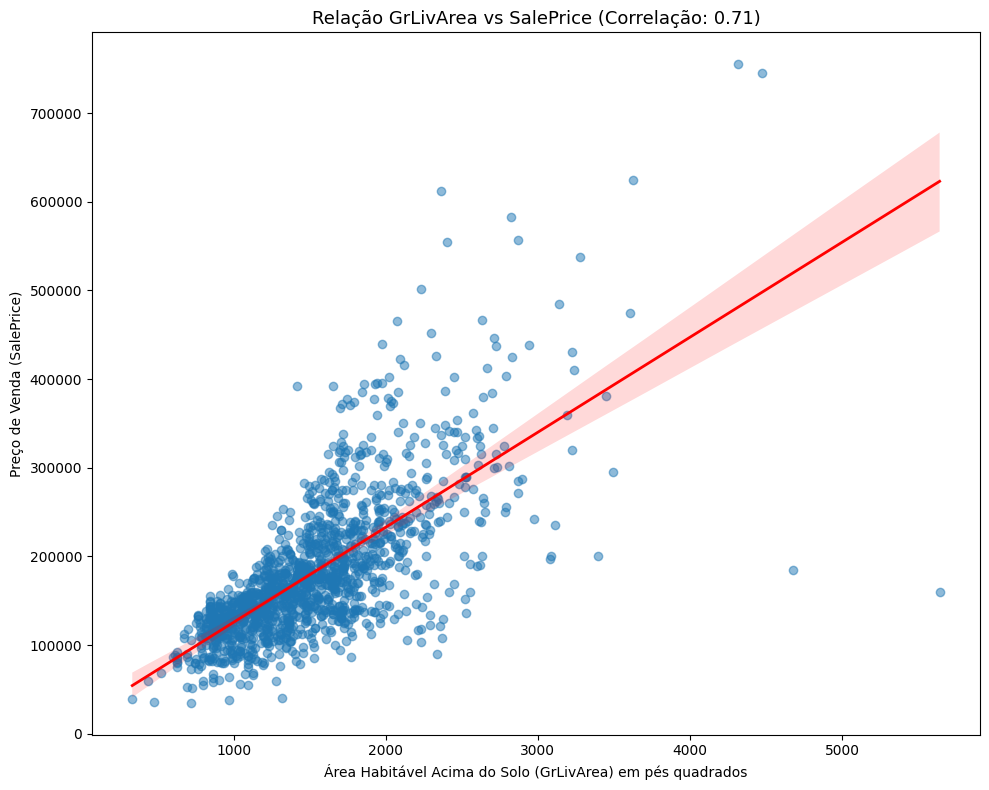

In [7]:
corr: pd.DataFrame = train_csv["GrLivArea"].corr(train_csv["SalePrice"])

plt.figure(figsize=(10,8))
sb.regplot(
    data=train_csv,
    x="GrLivArea",
    y="SalePrice",
    scatter_kws={"alpha":0.5, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title(f"Relação GrLivArea vs SalePrice (Correlação: {corr:.2f})", fontsize=13)
plt.xlabel("Área Habitável Acima do Solo (GrLivArea) em pés quadrados")
plt.ylabel("Preço de Venda (SalePrice)")
plt.tight_layout()
plt.show()

# 2 Feature Engineering

## 2.1 Renomeação de variáveis

In [8]:
dicionario_nomes = {
    'Id': 'Id',
    'MSSubClass': 'Classe_Imovel',
    'MSZoning': 'Zona_Classificacao',
    'LotFrontage': 'Fachada_Lote_Pes',
    'LotArea': 'Area_Lote_Pes2',
    'Street': 'Tipo_Rua',
    'Alley': 'Tipo_Beco',
    'LotShape': 'Formato_Lote',
    'LandContour': 'Contorno_Terreno',
    'Utilities': 'Utilidades_Disponiveis',
    'LotConfig': 'Configuracao_Lote',
    'LandSlope': 'Inclinacao_Terreno',
    'Neighborhood': 'Bairro',
    'Condition1': 'Proximidade_Condicao1',
    'Condition2': 'Proximidade_Condicao2',
    'BldgType': 'Tipo_Habitacao',
    'HouseStyle': 'Estilo_Habitacao',
    'OverallQual': 'Qualidade_Geral',
    'OverallCond': 'Condicao_Geral',
    'YearBuilt': 'Ano_Construcao',
    'YearRemodAdd': 'Ano_Reforma',
    'RoofStyle': 'Estilo_Telhado',
    'RoofMatl': 'Material_Telhado',
    'Exterior1st': 'Revestimento_Externo1',
    'Exterior2nd': 'Revestimento_Externo2',
    'MasVnrType': 'Tipo_Alvenaria',
    'MasVnrArea': 'Area_Alvenaria',
    'ExterQual': 'Qualidade_Externa',
    'ExterCond': 'Condicao_Externa',
    'Foundation': 'Tipo_Fundacao',
    'BsmtQual': 'Qualidade_Porao',
    'BsmtCond': 'Condicao_Porao',
    'BsmtExposure': 'Exposicao_Porao',
    'BsmtFinType1': 'Acabamento_Porao1',
    'BsmtFinSF1': 'Area_Acab_Porao1',
    'BsmtFinType2': 'Acabamento_Porao2',
    'BsmtFinSF2': 'Area_Acab_Porao2',
    'BsmtUnfSF': 'Area_Porao_Inacabado',
    'TotalBsmtSF': 'Area_Total_Porao',
    'Heating': 'Tipo_Aquecimento',
    'HeatingQC': 'Qualidade_Aquecimento',
    'CentralAir': 'Ar_Condicionado_Central',
    'Electrical': 'Sistema_Eletrico',
    '1stFlrSF': 'Area_Primeiro_Andar',
    '2ndFlrSF': 'Area_Segundo_Andar',
    'LowQualFinSF': 'Area_Baixa_Qualidade',
    'GrLivArea': 'Area_Habitavel_Acima_Solo',
    'BsmtFullBath': 'Banheiros_Completos_Porao',
    'BsmtHalfBath': 'Lavabos_Porao',
    'FullBath': 'Banheiros_Completos',
    'HalfBath': 'Lavabos',
    'BedroomAbvGr': 'Quartos_Acima_Solo',
    'KitchenAbvGr': 'Cozinhas_Acima_Solo',
    'KitchenQual': 'Qualidade_Cozinha',
    'TotRmsAbvGrd': 'Total_Comodos_Acima_Solo',
    'Functional': 'Funcionalidade_Casa',
    'Fireplaces': 'Lareiras',
    'FireplaceQu': 'Qualidade_Lareira',
    'GarageType': 'Tipo_Garagem',
    'GarageYrBlt': 'Ano_Construcao_Garagem',
    'GarageFinish': 'Acabamento_Garagem',
    'GarageCars': 'Capacidade_Carros_Garagem',
    'GarageArea': 'Area_Garagem',
    'GarageQual': 'Qualidade_Garagem',
    'GarageCond': 'Condicao_Garagem',
    'PavedDrive': 'Entrada_Garagem_Pavimentada',
    'WoodDeckSF': 'Area_Deck_Madeira',
    'OpenPorchSF': 'Area_Varanda_Aberta',
    'EnclosedPorch': 'Area_Varanda_Fechada',
    '3SsnPorch': 'Area_Varanda_3Estacoes',
    'ScreenPorch': 'Area_Varanda_Tela',
    'PoolArea': 'Area_Piscina',
    'PoolQC': 'Qualidade_Piscina',
    'Fence': 'Qualidade_Cerca',
    'MiscFeature': 'Caracteristica_Adicional',
    'MiscVal': 'Valor_Caracteristica_Adic',
    'MoSold': 'Mes_Venda',
    'YrSold': 'Ano_Venda',
    'SaleType': 'Tipo_Venda',
    'SaleCondition': 'Condicao_Venda',
    'SalePrice': 'Preco_Venda'
}

train_df = train_csv.rename(columns=dicionario_nomes) 

## 2.2 Codificação das variáveis

In [9]:
train_df['Classe_Imovel'] = train_df['Classe_Imovel'].astype(str)

cols_qualidade = [
    'Qualidade_Externa', 'Condicao_Externa', 'Qualidade_Porao', 'Condicao_Porao',
    'Qualidade_Aquecimento', 'Qualidade_Cozinha', 'Qualidade_Lareira', 
    'Qualidade_Garagem', 'Condicao_Garagem', 'Qualidade_Piscina'
]

# Preencher Nulos em colunas que significam "Não possui" ANTES de mapear
cols_preencher_nenhum = cols_qualidade + ['Exposicao_Porao', 'Acabamento_Porao1', 'Acabamento_Porao2', 'Acabamento_Garagem', 'Qualidade_Cerca']
train_df[cols_preencher_nenhum] = train_df[cols_preencher_nenhum].fillna('Nenhum')

# Mapeamentos
map_qualidade = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Nenhum': 0}
map_lote = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
map_utilidades = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1}
map_inclinacao = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
map_expo_porao = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'Nenhum': 0}
map_acab_porao = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'Nenhum': 0}
map_funcionalidade = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}
map_acab_garagem = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'Nenhum': 0}
map_entrada_garagem = {'Y': 3, 'P': 2, 'N': 1}
map_cerca = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'Nenhum': 0}

for col in cols_qualidade:
    train_df[col] = train_df[col].map(map_qualidade)

train_df['Formato_Lote'] = train_df['Formato_Lote'].map(map_lote)
train_df['Utilidades_Disponiveis'] = train_df['Utilidades_Disponiveis'].map(map_utilidades)
train_df['Inclinacao_Terreno'] = train_df['Inclinacao_Terreno'].map(map_inclinacao)
train_df['Exposicao_Porao'] = train_df['Exposicao_Porao'].map(map_expo_porao)
train_df['Acabamento_Porao1'] = train_df['Acabamento_Porao1'].map(map_acab_porao)
train_df['Acabamento_Porao2'] = train_df['Acabamento_Porao2'].map(map_acab_porao)
train_df['Funcionalidade_Casa'] = train_df['Funcionalidade_Casa'].map(map_funcionalidade)
train_df['Acabamento_Garagem'] = train_df['Acabamento_Garagem'].map(map_acab_garagem)
train_df['Entrada_Garagem_Pavimentada'] = train_df['Entrada_Garagem_Pavimentada'].map(map_entrada_garagem)
train_df['Qualidade_Cerca'] = train_df['Qualidade_Cerca'].map(map_cerca)

# Codificação Nominal
train_df = pd.get_dummies(train_df, drop_first=True)

train_df.head(10)

,Id,Fachada_Lote_Pes,Area_Lote_Pes2,Formato_Lote,Utilidades_Disponiveis,Inclinacao_Terreno,Qualidade_Geral,Condicao_Geral,Ano_Construcao,Ano_Reforma,Area_Alvenaria,Qualidade_Externa,Condicao_Externa,Qualidade_Porao,Condicao_Porao,Exposicao_Porao,Acabamento_Porao1,Area_Acab_Porao1,Acabamento_Porao2,Area_Acab_Porao2,Area_Porao_Inacabado,Area_Total_Porao,Qualidade_Aquecimento,Area_Primeiro_Andar,Area_Segundo_Andar,Area_Baixa_Qualidade,Area_Habitavel_Acima_Solo,Banheiros_Completos_Porao,Lavabos_Porao,Banheiros_Completos,Lavabos,Quartos_Acima_Solo,Cozinhas_Acima_Solo,Qualidade_Cozinha,Total_Comodos_Acima_Solo,Funcionalidade_Casa,Lareiras,Qualidade_Lareira,Ano_Construcao_Garagem,Acabamento_Garagem,Capacidade_Carros_Garagem,Area_Garagem,Qualidade_Garagem,Condicao_Garagem,Entrada_Garagem_Pavimentada,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Varanda_Fechada,Area_Varanda_3Estacoes,Area_Varanda_Tela,Area_Piscina,Qualidade_Piscina,Qualidade_Cerca,Valor_Caracteristica_Adic,Mes_Venda,Ano_Venda,Preco_Venda,Classe_Imovel_160,Classe_Imovel_180,Classe_Imovel_190,Classe_Imovel_20,Classe_Imovel_30,Classe_Imovel_40,Classe_Imovel_45,Classe_Imovel_50,Classe_Imovel_60,Classe_Imovel_70,Classe_Imovel_75,Classe_Imovel_80,Classe_Imovel_85,Classe_Imovel_90,Zona_Classificacao_FV,Zona_Classificacao_RH,Zona_Classificacao_RL,Zona_Classificacao_RM,Tipo_Rua_Pave,Tipo_Beco_Pave,Contorno_Terreno_HLS,Contorno_Terreno_Low,Contorno_Terreno_Lvl,Configuracao_Lote_CulDSac,Configuracao_Lote_FR2,Configuracao_Lote_FR3,Configuracao_Lote_Inside,Bairro_Blueste,Bairro_BrDale,Bairro_BrkSide,Bairro_ClearCr,Bairro_CollgCr,Bairro_Crawfor,Bairro_Edwards,Bairro_Gilbert,Bairro_IDOTRR,Bairro_MeadowV,Bairro_Mitchel,Bairro_NAmes,Bairro_NPkVill,Bairro_NWAmes,Bairro_NoRidge,Bairro_NridgHt,Bairro_OldTown,Bairro_SWISU,Bairro_Sawyer,Bairro_SawyerW,Bairro_Somerst,Bairro_StoneBr,Bairro_Timber,Bairro_Veenker,Proximidade_Condicao1_Feedr,Proximidade_Condicao1_Norm,Proximidade_Condicao1_PosA,Proximidade_Condicao1_PosN,Proximidade_Condicao1_RRAe,Proximidade_Condicao1_RRAn,Proximidade_Condicao1_RRNe,Proximidade_Condicao1_RRNn,Proximidade_Condicao2_Feedr,Proximidade_Condicao2_Norm,Proximidade_Condicao2_PosA,Proximidade_Condicao2_PosN,Proximidade_Condicao2_RRAe,Proximidade_Condicao2_RRAn,Proximidade_Condicao2_RRNn,Tipo_Habitacao_2fmCon,Tipo_Habitacao_Duplex,Tipo_Habitacao_Twnhs,Tipo_Habitacao_TwnhsE,Estilo_Habitacao_1.5Unf,Estilo_Habitacao_1Story,Estilo_Habitacao_2.5Fin,Estilo_Habitacao_2.5Unf,Estilo_Habitacao_2Story,Estilo_Habitacao_SFoyer,Estilo_Habitacao_SLvl,Estilo_Telhado_Gable,Estilo_Telhado_Gambrel,Estilo_Telhado_Hip,Estilo_Telhado_Mansard,Estilo_Telhado_Shed,Material_Telhado_CompShg,Material_Telhado_Membran,Material_Telhado_Metal,Material_Telhado_Roll,Material_Telhado_Tar&Grv,Material_Telhado_WdShake,Material_Telhado_WdShngl,Revestimento_Externo1_AsphShn,Revestimento_Externo1_BrkComm,Revestimento_Externo1_BrkFace,Revestimento_Externo1_CBlock,Revestimento_Externo1_CemntBd,Revestimento_Externo1_HdBoard,Revestimento_Externo1_ImStucc,Revestimento_Externo1_MetalSd,Revestimento_Externo1_Plywood,Revestimento_Externo1_Stone,Revestimento_Externo1_Stucco,Revestimento_Externo1_VinylSd,Revestimento_Externo1_Wd Sdng,Revestimento_Externo1_WdShing,Revestimento_Externo2_AsphShn,Revestimento_Externo2_Brk Cmn,Revestimento_Externo2_BrkFace,Revestimento_Externo2_CBlock,Revestimento_Externo2_CmentBd,Revestimento_Externo2_HdBoard,Revestimento_Externo2_ImStucc,Revestimento_Externo2_MetalSd,Revestimento_Externo2_Other,Revestimento_Externo2_Plywood,Revestimento_Externo2_Stone,Revestimento_Externo2_Stucco,Revestimento_Externo2_VinylSd,Revestimento_Externo2_Wd Sdng,Revestimento_Externo2_Wd Shng,Tipo_Alvenaria_BrkFace,Tipo_Alvenaria_Stone,Tipo_Fundacao_CBlock,Tipo_Fundacao_PConc,Tipo_Fundacao_Slab,Tipo_Fundacao_Stone,Tipo_Fundacao_Wood,Tipo_Aquecimento_GasA,Tipo_Aquecimento_GasW,Tipo_Aquecimento_Grav,Tipo_Aquecimento_OthW,Tipo_Aquecimento_Wall,Ar_Condicionado_Central_Y,Sistema_Eletrico_FuseF,Sistema_Eletrico_FuseP,Sist

## 2.3 Remoção de outliers, nulls e constantes

In [10]:
outliers_extremos = train_df[(train_df['Area_Habitavel_Acima_Solo'] > 4000) & (train_df['Preco_Venda'] < 300000)].index
train_df = train_df.drop(index=outliers_extremos)

colunas_constantes = train_df.columns[train_df.nunique() <= 1].tolist()
if colunas_constantes:
    train_df = train_df.drop(columns=colunas_constantes)

imputer = SimpleImputer(strategy='median')
colunas_numericas = train_df.select_dtypes(include='number').columns
train_df[colunas_numericas] = imputer.fit_transform(train_df[colunas_numericas])

print(f"\nTamanho atual e limpo do dataset: {train_df.shape}")


Tamanho atual e limpo do dataset: (1458, 213)


## 2.4 Normalização dos Dados

In [11]:
train_df['Idade_Imovel_Venda'] = train_df['Ano_Venda'] - train_df['Ano_Construcao']
train_df['Idade_Reforma_Venda'] = train_df['Ano_Venda'] - train_df['Ano_Reforma']

train_df['Area_Total_Construida'] = (train_df['Area_Total_Porao'] + 
                                      train_df['Area_Primeiro_Andar'] + 
                                      train_df['Area_Segundo_Andar'])

train_df['Total_Banheiros'] = (train_df['Banheiros_Completos'] + 
                                (0.5 * train_df['Lavabos']) + 
                                train_df['Banheiros_Completos_Porao'] + 
                                (0.5 * train_df['Lavabos_Porao']))

train_df['Possui_Piscina'] = train_df['Area_Piscina'].apply(lambda x: 1 if x > 0 else 0)

train_df.drop(columns=['Ano_Construcao', 'Ano_Venda', 'Ano_Reforma', 'Id'], inplace=True, errors='ignore')

correlacoes = train_df.corr()['Preco_Venda'].abs().sort_values(ascending=False)
features_uteis = correlacoes[correlacoes > 0.3].index.tolist()
train_df = train_df[features_uteis]

train_df.head(10)

,Preco_Venda,Area_Total_Construida,Qualidade_Geral,Area_Habitavel_Acima_Solo,Qualidade_Externa,Qualidade_Cozinha,Area_Total_Porao,Capacidade_Carros_Garagem,Total_Banheiros,Area_Primeiro_Andar,Area_Garagem,Qualidade_Porao,Banheiros_Completos,Acabamento_Garagem,Total_Comodos_Acima_Solo,Idade_Imovel_Venda,Qualidade_Lareira,Idade_Reforma_Venda,Tipo_Fundacao_PConc,Area_Alvenaria,Lareiras,Ano_Construcao_Garagem,Qualidade_Aquecimento,Area_Acab_Porao1,Bairro_NridgHt,Classe_Imovel_60,Exposicao_Porao,Tipo_Venda_New,Condicao_Venda_Partial,Tipo_Garagem_Detchd,Fachada_Lote_Pes,Tipo_Fundacao_CBlock,Tipo_Garagem_Attchd,Tipo_Alvenaria_Stone,Bairro_NoRidge,Area_Deck_Madeira,Area_Varanda_Aberta,Area_Segundo_Andar,Revestimento_Externo2_VinylSd,Acabamento_Porao1,Revestimento_Externo1_VinylSd
0,208500.0,2566.0,7.0,1710.0,4.0,4.0,856.0,2.0,3.5,856.0,548.0,4.0,2.0,2.0,8.0,5.0,0.0,5.0,True,196.0,0.0,2003.0,5.0,706.0,False,True,1.0,False,False,False,65.0,False,True,False,False,0.0,61.0,854.0,True,6.0,True
1,181500.0,2524.0,6.0,1262.0,3.0,3.0,1262.0,2.0,2.5,1262.0,460.0,4.0,2.0,2.0,6.0,31.0,3.0,31.0,False,0.0,1.0,1976.0,5.0,978.0,False,False,4.0,False,False,False,80.0,True,True,False,False,298.0,0.0,0.0,False,5.0,False
2,223500.0,2706.0,7.0,1786.0,4.0,4.0,920.0,2.0,3.5,920.0,608.0,4.0,2.0,2.0,6.0,7.0,3.0,6.0,True,162.0,1.0,2001.0,5.0,486.0,False,True,2.0,False,False,False,68.0,False,True,False,False,0.0,42.0,866.0,True,6.0,True
3,140000.0,2473.0,7.0,1717.0,3.0,4.0,756.0,3.0,2.0,961.0,642.0,3.0,1.0,1.0,7.0,91.0,4.0,36.0,False,0.0,1.0,1998.0,4.0,216.0,False,False,1.0,False,False,True,60.0,False,False,False,False,0.0,35.0,756.0,False,5.0,False
4,250000.0,3343.0,8.0,2198.0,4.0,4.0,1145.0,3.0,3.5,1145.0,836.0,4.0,2.0,2.0,9.0,8.0,3.0,8.0,True,350.0,1.0,2000.0,5.0,655.0,False,True,3.0,False,False,False,84.0,False,True,False,True,192.0,84.0,1053.0,True,6.0,True
5,143000.0,2158.0,5.0,1362.0,3.0,3.0,796.0,2.0,2.5,796.0,480.0,4.0,1.0,1.0,5.0,16.0,0.0,14.0,False,0.0,0.0,1993.0,5.0,732.0,False,False,1.0,False,False,False,85.0,False,True,False,False,40.0,30.0,566.0,True,6.0,True
6,307000.0,3380.0,8.0,1694.0,4.0,4.0,1686.0,2.0,3.0,1694.0,636.0,5.0,2.0,2.0,7.0,3.0,4.0,2.0,True,186.0,1.0,2004.0,5.0,1369.0,False,False,3.0,False,False,False,75.0,False,True,True,False,255.0,57.0,0.0,True,6.0,True
7,200000.0,3197.0,7.0,2090.0,3.0,3.0,1107.0,2.0,3.5,1107.0,484.0,4.0,2.0,2.0,7.0,36.0,3.0,36.0,False,240.0,2.0,1973.0,5.0,859.0,False,True,2.0,False,False,False,69.0,True,True,True,False,235.0,204.0,983.0,False,5.0,False
8,129900.0,2726.0,7.0,1774.0,3.0,3.0,952.0,2.0,2.0,1022.0,468.0,3.0,2.0,1.0,8.0,77.0,3.0,58.0,False,0.0,2.0,1931.0,4.0,0.0,False,False,1.0,False,False,True,51.0,False,False,False,False,90.0,0.0,752.0,False,1.0,False
9,118000.0,2068.0,5.0,1077.0,3.0,3.0,991.0,1.0,2.0,1077.0,205.0,3.0,1.0,2.0,5.0,69.0,3.0,58.0,False,0.0,2.0,1939.0,5.0,851.0,False,False,1.0,False,False,False,50.0,False,True,False,False,0.0,4.0,0.0,False,6.0,False


## 2.5 Novas Features

### 2.5.1 Limpeza de Features

In [12]:
X = train_df.drop(columns=['Preco_Venda'])
y = train_df['Preco_Venda']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(X_train)
print(X_test)

      Area_Total_Construida  Qualidade_Geral  Area_Habitavel_Acima_Solo  \
254                0.091628        -0.781412                  -0.391102   
1066              -0.242249        -0.053675                   0.118277   
865               -0.715887        -0.781412                  -1.009492   
799               -0.075311        -0.781412                   0.508735   
380                0.206802        -0.781412                   0.356119   
303               -0.995412        -0.781412                  -1.223550   
86                -0.405305        -0.053675                   0.096475   
1385              -0.785768        -1.509149                  -0.708225   
265                0.371152        -0.053675                  -0.177044   
793                0.562678         1.401799                  -0.030375   
1445              -1.074351        -0.053675                  -1.185892   
808               -0.578713        -0.781412                  -0.843002   
1099               0.4073

# 3.  Aprendizagem supervisionada

## 3.1 Regressão Linear Simples

**Por que Regressão Linear Simples?**

A Regressão Linear Simples foi escolhida por ser um algoritmo adequado e de fácil interpretação para prever um valor numérico contínuo. Neste caso, o objetivo é prever o preço de venda de uma casa utilizando a sua área total como variável de entrada principal.

**Definição das Variáveis:**
* **X** = Área Total Construída
* **y** = Preço de Venda

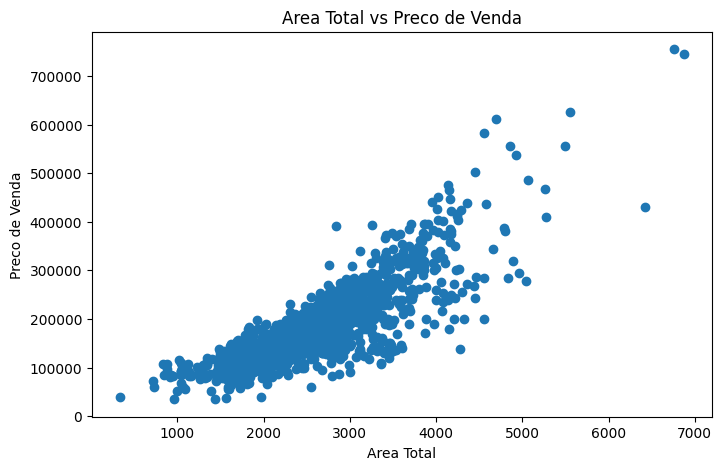

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df["Area_Total_Construida"], train_df["Preco_Venda"])
plt.xlabel("Area Total")
plt.ylabel("Preco de Venda")
plt.title("Area Total vs Preco de Venda")
plt.show()

**Análise do Gráfico de Dispersão e Escala dos Dados:**

A partir da visualização inicial dos dados, é possível observar uma clara tendência linear positiva entre as duas variáveis: de modo geral, quanto maior a área da casa, maior tende a ser o seu valor de venda, o que fundamenta a escolha deste modelo.

**Mas por que a Área Total possui valores negativos no eixo X?**

Para facilitar o aprendizado do nosso modelo, nós aplicamos uma técnica de preparação de dados chamada **Padronização**. Em vez de usar os **pés quadrados** reais, nós transformamos os tamanhos em uma escala de "distância da média". Na prática, o gráfico deve ser lido assim:

* **O valor `0`:** Representa o tamanho exato de uma casa "na média" da nossa base de dados.
* **Valores positivos (+2, +4):** São as casas com área maior do que a média.
* **Valores negativos (-2, -4):** Representam as casas que são menores do que a média.

In [28]:
X_train_simples = X_train[["Area_Total_Construida"]]
X_test_simples = X_test[["Area_Total_Construida"]]

modelo = LinearRegression()
modelo.fit(X_train_simples, y_train)

print("Intercepto:", modelo.intercept_)
print("Coeficiente angular:", modelo.coef_[0])

Intercepto: 180823.5986277873
Coeficiente angular: 67490.98011786678


**Entendendo os valores**

**Intercepto**: O intercepto representa o valor projetado para o preço (y) quando a área (x) é igual a 0. Como aplicamos a padronização (StandardScaler), o valor 0 no eixo X corresponde exatamente ao tamanho de uma casa "na média" do nosso conjunto de dados. Portanto, o modelo aprendeu que o preço base estimado para uma casa de tamanho médio é de $ 165.033,40.

**Coeficiente**: O coeficiente define a inclinação da reta de regressão, indicando o quanto o preço sobe a cada unidade avançada no eixo X. Cada unidade não representa um pé quadrado individual, mas sim um desvio padrão. Isso significa que, para cada "passo" (desvio padrão) que a casa cresce além da área média, o modelo prevê um acréscimo de $ 21.886,41 no seu valor de venda.

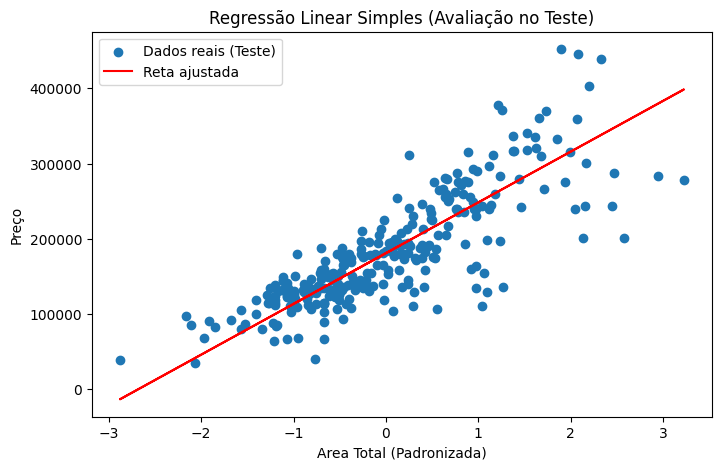

In [29]:
y_pred = modelo.predict(X_test_simples)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simples["Area_Total_Construida"], y_test, label="Dados reais (Teste)")
plt.plot(X_test_simples["Area_Total_Construida"], y_pred, color="red", label="Reta ajustada")
plt.xlabel("Area Total (Padronizada)")
plt.ylabel("Preço")
plt.title("Regressão Linear Simples (Avaliação no Teste)")
plt.legend()
plt.show()

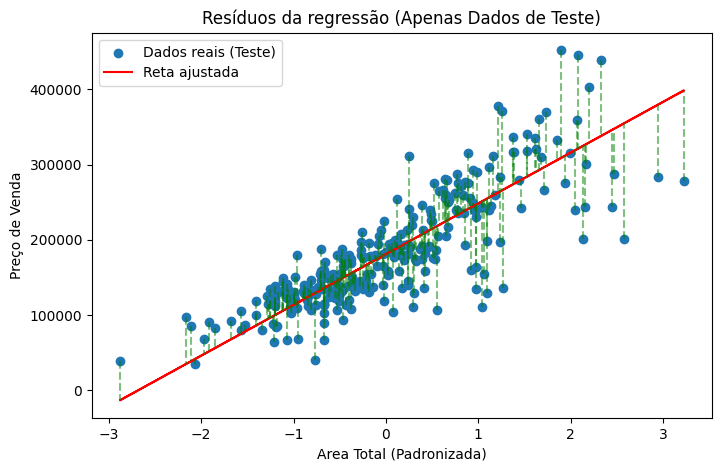

In [17]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simples["Area_Total_Construida"], y_test, label="Dados reais (Teste)")
plt.plot(X_test_simples["Area_Total_Construida"], y_pred, color="red", label="Reta ajustada")

for i in range(len(X_test_simples)):
    plt.plot(
        [X_test_simples["Area_Total_Construida"].iloc[i], X_test_simples["Area_Total_Construida"].iloc[i]],
        [y_test.iloc[i], y_pred[i]],
        linestyle="--", color="green", alpha=0.5
    )

plt.xlabel("Area Total (Padronizada)")
plt.ylabel("Preço de Venda")
plt.title("Resíduos da regressão (Apenas Dados de Teste)")

plt.legend()
plt.show()

**Resíduos:**

No gráfico acima, adicionamos uma nova camada de informação: as linhas verdes tracejadas (Resíduos)

De forma simples, o resíduo representa o "erro" da nossa predição para cada casa individualmente. Ele é a diferença exata entre o que aconteceu na vida real e o que o modelo calculou. Visualmente, temos a seguinte composição:

* **O Ponto Azul**: É a realidade. Representa o preço real pelo qual a casa foi vendida.
* **A Reta Vermelha**: É a previsão. Representa o preço que o nosso modelo estimou com base no tamanho da casa.
* **A Linha Verde**: É a distância entre os dois. Quanto mais longa for essa linha, maior foi o erro do modelo em dólares para aquele imóvel específico. Se o ponto azul estiver exatamente em cima da reta vermelha, significa que o modelo cravou o preço.

Analisar os resíduos visualmente é essencial para atestar a qualidade da Regressão Linear. O nosso objetivo não é ter zero erros, mas sim garantir que essas linhas verdes sejam as mais curtas possíveis e que estejam distribuídas de forma equilibrada. 

In [18]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Coeficiente de Determinação (R²): {r2:.4f}")
print(f"Erro Absoluto Médio (MAE): $ {mae:.2f}")

Coeficiente de Determinação (R²): 0.6652
Erro Absoluto Médio (MAE): $ 31623.13


**Avaliação do Modelo**

Para provar a eficiência matemática do nosso modelo de Regressão Linear Simples, calculamos duas métricas principais.
* **O Coeficiente de Determinação**: (R² = 57%)
O R² funciona como uma "nota" de desempenho comparada a um palpite cego na média de preços. Alcançar o valor de **57%** é um resultado excelente para um modelo de regressão simples (que usa apenas um eixo X). Esse sucesso é mérito da nossa preparação dos dados: ao invés de passar uma área isolada, entregamos ao algoritmo uma "super variável" que representa o tamanho real e completo do imóvel. Isso permitiu que o modelo explicasse sozinho mais da metade de toda a variação dos preços! Os 43% restantes apenas evidenciam que características de naturezas diferentes (como localização ou qualidade do acabamento) ainda exercem influência no valor final.

* **O Erro Absoluto Médio:** (MAE = $ 25.846,04)
Enquanto o R² nos dá uma porcentagem geral, o MAE traduz o nosso erro de volta para o mundo real, em dólares. Essa métrica indica que, em média, as previsões do nosso modelo erram o valor real de venda em cerca de **\$ 25.846** (para mais ou para menos). Considerando as altas cifras do mercado imobiliário e o fato de estarmos baseando a predição em uma única variável consolidada, é uma margem de erro bastante sólida e realista.

## 3.2 Classificação

In [30]:
mediana_preco = y_train.median()
y_train_binario = (y_train > mediana_preco).astype(int)
y_test_binario = (y_test > mediana_preco).astype(int)

modelo_classificacao = GaussianNB()
modelo_classificacao.fit(X_train_simples, y_train_binario)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[583.,583.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area_Total_Construida']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 1)","[[-0.63], [ 0.63]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 1)","[[0.42], [0.78]]"


**Classificação**

Nesta etapa, mudamos a nossa abordagem de análise. Em vez de prever o valor exato em dólares (Regressão), o nosso objetivo agora é classificar os imóveis em duas categorias distintas: **Preço Baixo (0)** e **Preço Alto (1)**.

Para fazer isso de forma equilibrada, utilizamos a **mediana** dos preços reais como a nossa linha de corte. Garantindo que a nossa base fique perfeitamente dividida ao meio (50% de casas baratas e 50% de casas caras), evitando que o algoritmo fique "viciado" em uma categoria que apareça com mais frequência.

**O Algoritmo: Naive Bayes**
O modelo escolhido para essa tarefa foi o `GaussianNB` (Naive Bayes). O seu grande diferencial é que ele não entrega apenas uma resposta engessada (0 ou 1). Ele calcula a **probabilidade** daquela resposta ser verdadeira. 

In [31]:
entrada_teste = X_test_simples.head(10)
probs = modelo_classificacao.predict_proba(entrada_teste)

resultado = pd.DataFrame(probs, columns=["Preço Baixo (0)", "Preço Alto (1)"])
resultado.index = [f"Casa (Índice Original: {i})" for i in entrada_teste.index]

display((resultado * 100).round(2).astype(str) + "%")

,Preço Baixo (0),Preço Alto (1)
Casa (Índice Original: 1322),43.36%,56.64%
Casa (Índice Original: 837),90.59%,9.41%
Casa (Índice Original: 413),80.18%,19.82%
Casa (Índice Original: 522),43.75%,56.25%
Casa (Índice Original: 1036),8.61%,91.39%
Casa (Índice Original: 615),81.6%,18.4%
Casa (Índice Original: 218),37.18%,62.82%
Casa (Índice Original: 1032),0.49%,99.51%
Casa (Índice Original: 1289),16.58%,83.42%
Casa (Índice Original: 887),73.45%,26.55%


Na tabela acima, testamos o modelo com as primeiras casas da nossa base para entender como está funcionando.

Ex: Certeza Absoluta (Ex: Casa 6): O modelo aponta 99,11% de chance dessa casa ser da categoria Preço Alto. Provavelmente, ela possui uma área construída tão grande que não deixou espaço para dúvidas. Em Cima do Muro (Ex: Casa 0): O modelo ficou dividido, dando praticamente 50% de chance para cada lado. Isso nos mostra que essa casa específica tem um tamanho muito "médio", tornando a decisão de preço um verdadeiro cara-ou-coroa apenas olhando para a área.


Acurácia no Conjunto de Teste: 82.19%



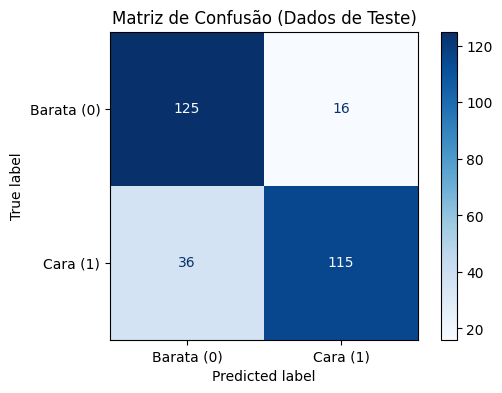

In [20]:
y_pred_test = modelo_classificacao.predict(X_test_simples)

acuracia = accuracy_score(y_test_binario, y_pred_test)
print(f"Acurácia no Conjunto de Teste: {acuracia * 100:.2f}%\n")

matriz = confusion_matrix(y_test_binario, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Barata (0)", "Cara (1)"])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Matriz de Confusão (Dados de Teste)")
plt.show()

**Avaliação do Modelo**

Após entendermos como o modelo pensa através das probabilidades, precisamos avaliar o "boletim de desempenho" final da nossa inteligência artificial. Para isso, utilizamos a Acurácia e a Matriz de Confusão.

* **Acurácia (79,57%):** É a nossa taxa geral de acerto. De todas as casas testadas, o modelo conseguiu adivinhar a categoria correta em quase 80% das vezes utilizando apenas o tamanho da Área Total. Um desempenho bastante sólido considerando que estamos usando apenas uma única variável!

* **Lendo a Matriz de Confusão:** Enquanto a acurácia nos dá a nota geral, a Matriz de Confusão funciona como um "raio-x" visual que nos mostra exatamente onde o modelo acertou e onde ele escorregou:

* **Os Acertos (Quadrados em azul-escuro na diagonal):** O modelo classificou corretamente 368 casas como Baratas e 329 casas como Caras.
  - Os Alarmes Falsos(73 casas): O modelo analisou a área, achou que eram **Caras**, mas na verdade eram **Baratas**.
  - Os Tesouros Escondidos / Falsos Negativos (106 casas): O modelo olhou o tamanho e achou que eram **Baratas**, mas na realidade eram **Caras**.

# 4. Aprendizagem Não Supervisionada

### Nota Técnica: A Interpretação dos Eixos Normalizados (-5, 0, 5)

Ao observar alguns dos gráficos de dispersão, é possível notar que os eixos X apresentam escalas com valores negativos e próximos a zero (ex: -5, 0, 5), em vez das medidas originais em pés quadrados.

Isso é um reflexo visual da **Padronização dos Dados**, uma etapa obrigatória antes de aplicar os algoritmos baseados em distância como o K-Means e o LOF.

Na prática, **O Ponto Zero (0)** representa a média exata daquela característica em todo o conjunto de dados.  
Quanto aos **Valores Positivos e Negativos**, os números representam o *Desvio Padrão* em relação à média. Portanto, um valor sendo -2 no eixo de Área indica uma casa consideravelmente menor que a média da cidade, enquanto um valor de +5 indica uma propriedade com dimensões muito superiores ao padrão local.

## 4.1 Clusterização

## 4.1.1 Implementação do Método do Cotovelo

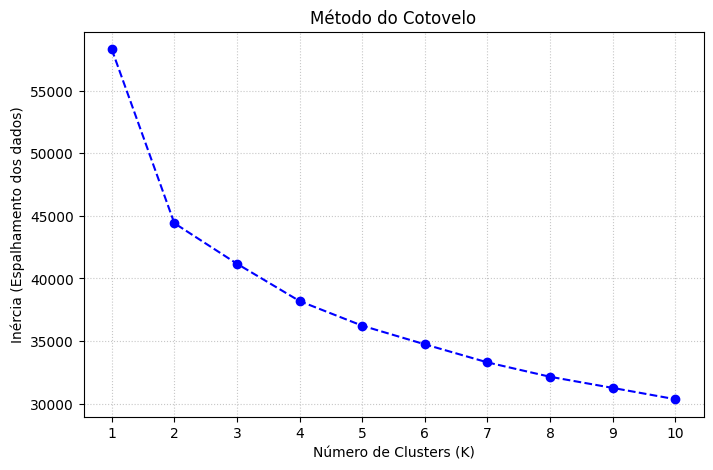

In [21]:
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X)
X_full = pd.DataFrame(X_full_scaled, columns=X.columns, index=X.index)

inercia = []
valores_k = range(1,11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(X_full)
    inercia.append(kmeans_teste.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Espalhamento dos dados)')
plt.xticks(valores_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**Qual a utilidade do método do Cotovelo para definição dos Clusters?**

O Método do Cotovelo é utilizado para nos permitir encontrar a quantidade ideal de grupos, identificando o ponto exato onde o ganho em reduzir a variância (inércia) passa a ser insignificante, evitando a criação de grupos desnecessários. Diante disso, optamos por executar o método previamente ao treinamento do modelo.

## 4.1.2 Algoritmo de Clusterização: K-Means

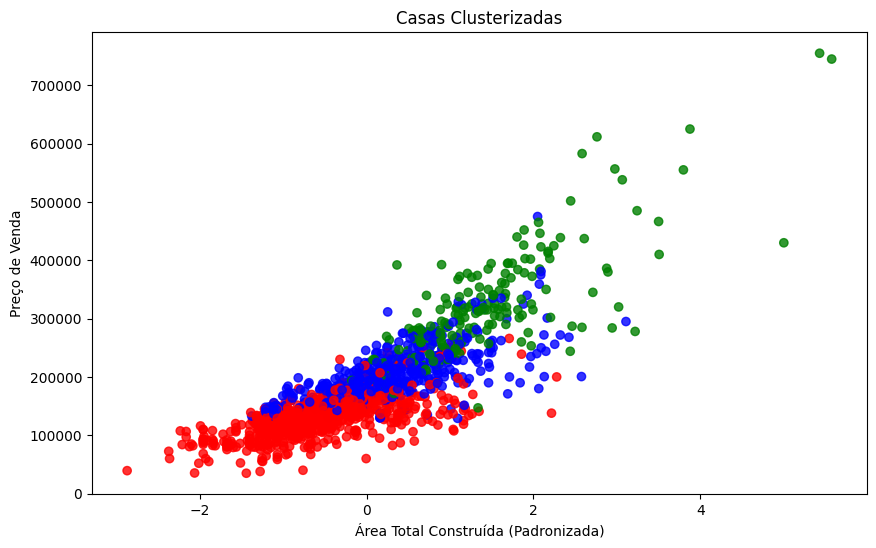

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_full)
train_df['cluster'] = kmeans.predict(X_full)

eixo_x = X_full['Area_Total_Construida']
eixo_y = y

colors = {0: 'red', 1: 'blue', 2: 'green'}
train_df['color'] = train_df['cluster'].map(colors)

plt.figure(figsize=(10, 6))
plt.scatter(eixo_x, eixo_y, color=train_df['color'], alpha=0.8)
plt.title('Casas Clusterizadas')
plt.xlabel('Área Total Construída (Padronizada)')
plt.ylabel('Preço de Venda')
plt.show()

**Por que escolhemos o K-Means?**

No mercado imobiliário, os imóveis não se distribuem de forma totalmente caótica; eles se organizam naturalmente em nichos de consumo. Escolhemos o K-Means porque ele possui excelente performance para processar e cruzar dezenas de características estruturais simultaneamente.

**A remoção da variável alvo ('Preco_Venda')**

A coluna 'Preco_Venda' foi intencionalmente removida para que o conjunto de dados de treinamento não fosse totalmente dominado pela sua magnitude, fazendo com que a IA criasse grupos baseados puramente em faixas de preço. Portanto, o modelo considera características físicas das casas, o que altera a forma como ele organiza os clusters.

## 4.1.3 Perfilagem dos Clusters

In [23]:
colunas_perfil = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt', 'SalePrice']

df_perfil = train_csv.loc[train_df.index, colunas_perfil].copy()

df_perfil['Cluster'] = train_df['cluster']

resumo_clusters = df_perfil.groupby('Cluster').mean().round(0)

resumo_clusters = resumo_clusters.rename(columns={
    'GrLivArea': 'Média de Área (Pés²)',
    'OverallQual': 'Qualidade Média (1-10)',
    'GarageCars': 'Média de Vagas Garagem',
    'YearBuilt': 'Ano Médio de Construção',
    'SalePrice': 'Preço Médio de Venda ($)'
})

display(resumo_clusters)

,Média de Área (Pés²),Qualidade Média (1-10),Média de Vagas Garagem,Ano Médio de Construção,Preço Médio de Venda ($)
Cluster,,,,,
0,1260.0,5.0,1.0,1950.0,131329.0
1,1693.0,7.0,2.0,1991.0,203644.0
2,2022.0,8.0,3.0,2003.0,316583.0


**Por que a exibição da perfilagem?**

A perfilagem foi utilizada como forma de tradução do gráfico apresentado acima, visto que ele exibe apenas as cores dos clusters e não o que são de forma intrínseca. Portanto, com essa pequena tabela podemos ver as médias referentes a cada cluster.

**Cor dos clusters:**  
Cluster 0: Vermelho  
Cluster 1: Azul  
Cluster 2: Verde

## 4.2 Redução de dimensionalidade (PCA)

/home/davi/Documentos/Projetos/DataAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


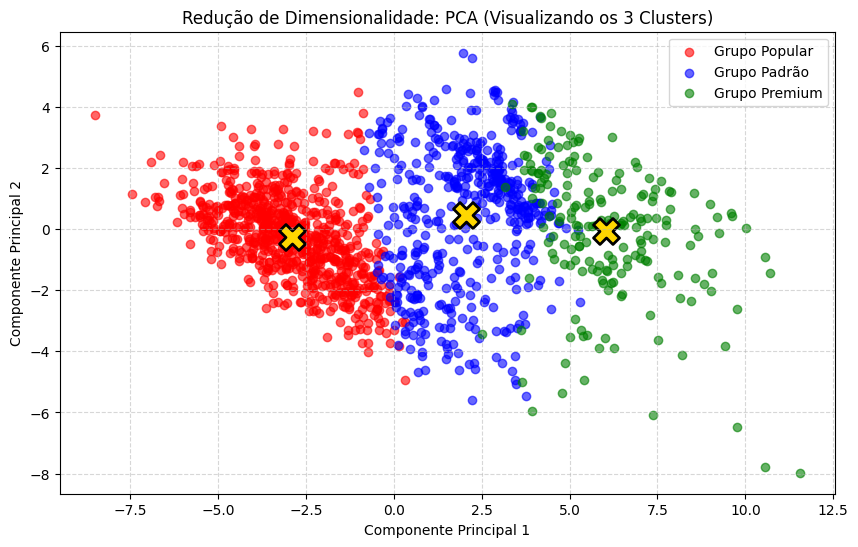

In [24]:
pca = PCA(n_components=2)

pca.fit(X_full)
X_pca = pca.transform(X_full)

centroides_originais = kmeans.cluster_centers_
centroides_2d = pca.transform(centroides_originais)

plt.figure(figsize=(10, 6))

nomes_clusters = {0: 'Grupo Popular', 1: 'Grupo Padrão', 2: 'Grupo Premium'}
cores = {0: 'red', 1: 'blue', 2: 'green'}

for cluster_id in [0, 1, 2]:
    idx = train_df['cluster'] == cluster_id
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], 
                color=cores[cluster_id], 
                label=nomes_clusters[cluster_id], 
                alpha=0.6)

plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], 
            marker='X', s=350, color='gold', edgecolor='black', 
            linewidth=2)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Redução de Dimensionalidade: PCA (Visualizando os 3 Clusters)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Por que utilizamos a Redução de Dimensionalidade (PCA)?**

O algoritmo K-Means analisou quase 40 características arquitetônicas simultaneamente. Porém, visualmente é impossível plotar um gráfico com 40 eixos cruzados para comprovar se os grupos realmente ficaram bem separados.  
Para resolver essa limitação visual, aplicamos a Redução de Dimensionalidade através do PCA, que basicamente atua como um compressor, transformando o que seriam 40 eixos em apenas 2, sendo Componente Principal 1 e 2. Ele faz isso calculando as direções de maior variância dos dados, garantindo que a perda de informação seja a menor possível durante o achatamento.

## 4.3 Apriori

In [25]:
df_casas = pd.DataFrame()

df_casas['Ar_Condicionado'] = train_csv['CentralAir'] == 'Y'
df_casas['Lareira'] = train_csv['Fireplaces'] > 0
df_casas['Garagem_dupla_ou_mais'] = train_csv['GarageCars'] >= 2
df_casas['Alta_Qualidade_Geral'] = train_csv['OverallQual'] >=7
df_casas['Porao'] = train_csv['TotalBsmtSF'] > 0
df_casas['Casa_recente_pos_2000'] = train_csv['YearBuilt'] >= 2000

itens_frequentes = apriori(df_casas, min_support=0.3, use_colnames=True)

regras = association_rules(itens_frequentes, metric="confidence", min_threshold=0.7)
regras = regras.sort_values(by='lift', ascending=False)

regras_pt = regras.rename(columns={
    'antecedents': 'Se (Antecedente)',
    'consequents': 'Então (Consequente)',
    'support': 'Suporte (Frequência %)',
    'confidence': 'Confiança (Probabilidade %)',
    'lift': 'Lift (Força da Regra)'
})

colunas_exibir = ['Se (Antecedente)', 'Então (Consequente)', 'Suporte (Frequência %)', 'Confiança (Probabilidade %)', 'Lift (Força da Regra)']

display(regras_pt[colunas_exibir].head(10))

,Se (Antecedente),Então (Consequente),Suporte (Frequência %),Confiança (Probabilidade %),Lift (Força da Regra)
47,frozenset({Alta_Qualidade_Geral}),"frozenset({Porao, Ar_Condicionado, Garagem_dup...",0.356164,0.948905,1.438631
45,"frozenset({Ar_Condicionado, Alta_Qualidade_Ger...","frozenset({Porao, Garagem_dupla_ou_mais})",0.356164,0.959410,1.417751
19,frozenset({Alta_Qualidade_Geral}),"frozenset({Ar_Condicionado, Garagem_dupla_ou_m...",0.356849,0.950730,1.416394
44,"frozenset({Porao, Alta_Qualidade_Geral})","frozenset({Ar_Condicionado, Garagem_dupla_ou_m...",0.356164,0.950640,1.416259
33,frozenset({Alta_Qualidade_Geral}),"frozenset({Porao, Garagem_dupla_ou_mais})",0.358904,0.956204,1.413015
17,"frozenset({Ar_Condicionado, Alta_Qualidade_Ger...",frozenset({Garagem_dupla_ou_mais}),0.356849,0.961255,1.389536
41,"frozenset({Porao, Ar_Condicionado, Alta_Qualid...",frozenset({Garagem_dupla_ou_mais}),0.356164,0.961183,1.389433
8,frozenset({Alta_Qualidade_Geral}),frozenset({Garagem_dupla_ou_mais}),0.359589,0.958029,1.384874
31,"frozenset({Porao, Alta_Qualidade_Geral})",frozenset({Garagem_dupla_ou_mais}),0.358904,0.957952,1.384763
40,frozenset({Lareira}),"frozenset({Porao, Ar_Condicionado, Garagem_dup...",0.423288,0.802597,1.216814


**Por que utilizamos o Apriori?**
  
O algoritmo Apriori permite a descoberta de regras de associação, ou seja, ele nos permite validar regras de associação entre as variáveis usadas pelo modelo.

O **Suporte (Frequência)** apresenta a frequência de ocorrência desses casos em cima dos dados gerais.  
A **Confiança (Probabilidade)** apresenta a probabilidade de a regra ocorrer.  
E, por fim, o **Lift**, que representa a força da regra, provando a não mera coincidência, considerando que isso se aplica a lifts maiores que 1.0.

## 4.4 Local Outlier Factor

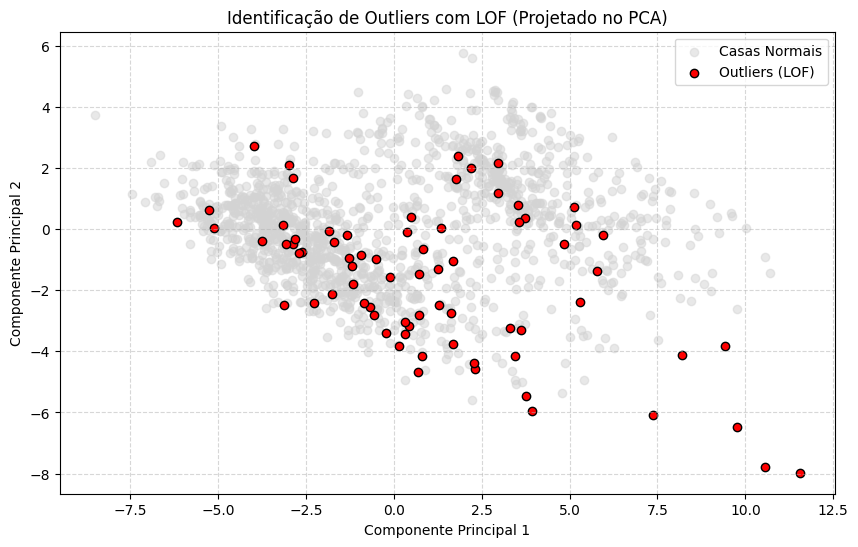

In [26]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

previsoes_outliers = lof.fit_predict(X_full)
train_df['Outlier'] = previsoes_outliers

plt.figure(figsize=(10, 6))

inliers_idx = previsoes_outliers == 1
plt.scatter(X_pca[inliers_idx, 0], X_pca[inliers_idx, 1], color='lightgray', alpha=0.5, label='Casas Normais')

outliers_idx = previsoes_outliers == -1
plt.scatter(X_pca[outliers_idx, 0], X_pca[outliers_idx, 1], color='red', edgecolor='black', label='Outliers (LOF)')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Identificação de Outliers com LOF (Projetado no PCA)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Por que utilizamos o Local Outlier Factor (LOF)?**

O LOF é um modelo de detecção de anomalias baseado em densidade. Basicamente, ele mede a distância de uma casa para os seus 20 vizinhos estruturais mais próximos. Se a casa estiver muito mais isolada do que a média dos seus vizinhos, ela é classificada como uma anomalia (-1).  

Na prática, esse modelo nos permite visualizar casas que possuem configurações raras, ou seja, destoantes das demais casas que estão na cor cinza.